# Simulated Galaxies

We can learn a lot from observations/measurements of galaxies (as you saw in the last notebook). However, we also talked about how galaxies can be oriented in a certain direction to us, which limits our view of them. We said galaxies change over billions of years; even mergers are slow. And, we also said that some galaxies are too far away for us to see. These are all pretty big limitations!

Luckily for astronomers, we understand how they work pretty well (but not perfectly). We understand enough that we can tell a computer how galaxies work and then have the computer make, or simulate, a galaxy. The nice thing about having a computer simulate a galaxy is then we can watch the galaxy's entire life. We can also run experiments that we cannot do in real life. This allows us to watch mergers happen. 

## IllustrisTNG 

We will be looking at a computer simulation called IllustrisTNG. (The TNG stands for "the next generation" because this is the second simulation they made, and astronomers are Star Trek fans.) IllustrisTNG is a HUGE simulation with tens of thousands of galaxies in it. We will be using IllustrisTNG-100, which is the middle sized simulation. 

<br>

<center>
<div>
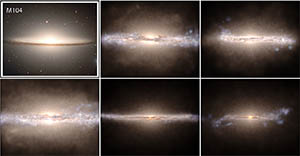
<div>
<center>
    
<center>    
The first panel shows the real Sombrero Galaxy. The other five panels show simulated galaxies from IllustrisTNG. Just from looking at these images, how do you think they did?
<center>
    
<br>    
    
    
Here is a video from the simulation that shows galaxies merging over "billions" of years: https://www.tng-project.org/movies/tng/tng100_sb0_latetype_formation.mp4 . You can find more videos and images here: https://www.tng-project.org/ .

## IllustrisTNG Data

Let's read in some data! As I said before, IllustrisTNG has tens of thousands of galaxies, so we are not going to look at all of them. Go look at the images in the Data/individual_analogs/images folder. Pick 3 galaxies (we can call simulated galaxies "analogs") that you're interested in. Each analog has an ID that is a number, which is in the name of the images. **Write down the IDs of the 3 galaxies you're interested in below**

**Galaxy 1:** 454539

**Galaxy 2:** 453081

**Galaxy 3:** 402293

In [3]:
# import the library
import pandas as pd

# read in the data for the first galaxy you chose
data1 = pd.read_csv('../Data/individual_analogs/454539_star_properties.csv') #add the name of the appropriate file)

In [4]:
# examine the data file by printing it below
data1

,g band,r band,age [Gyr]
0,-8.996834,-9.723399,3.184089
1,-8.579311,-9.305092,3.164129
2,-9.330316,-9.991377,2.409397
3,-8.810562,-9.538715,3.356489
4,-8.736373,-9.464674,3.379384
...,...,...,...
58112,-8.892896,-9.409117,12.731292
58113,-8.709400,-9.188172,12.227267
58114,-9.082513,-9.564348,13.077733
58115,-9.213364,-9.690534,11.909308


**How many rows are there?**

**Answer:** 58117

**How many columns are there?** 

**Answer:** 3


**Fill in the rows for each corresponding column**

| Column Header | Definition | Unit |
| :- | :- | :- |
| g band |the color magnitude (filter)  | no unit
| r band |the color magnitude (filter) | no unit
| age [Gyr] |the age of the stars  | Giga Year

In [5]:
# read in the data for your other two galaxies. They will have the same columns
data2 = pd.read_csv('../Data/individual_analogs/453081_star_properties.csv') #add the name of the appropriate file)
data3 = pd.read_csv('../Data/individual_analogs/402293_star_properties.csv') #add the name of the appropriate file)

In [7]:
data2

,g band,r band,age [Gyr]
0,-7.309444,-8.195689,10.856031
1,-8.330170,-9.236679,7.855232
2,-7.083546,-8.048851,10.707024
3,-7.120369,-8.064854,10.323297
4,-7.432516,-8.354740,10.332248
...,...,...,...
77402,-9.114698,-9.758924,6.082449
77403,-7.966639,-8.690153,9.271124
77404,-9.177384,-9.924151,6.693040
77405,-8.440053,-9.096263,3.975184


In [8]:
data3

,g band,r band,age [Gyr]
0,-8.046761,-8.816961,6.347111
1,-8.000262,-8.888894,7.544227
2,-8.242189,-9.012588,6.360210
3,-7.937858,-8.843595,7.517226
4,-8.133110,-8.992483,6.843228
...,...,...,...
63168,-8.388541,-9.066907,9.109745
63169,-9.321708,-9.870861,12.149096
63170,0.000000,0.000000,13.800000
63171,-8.236311,-8.718164,13.085381


**Rank your galaxies in terms of having the most star particles to the least**

**Response:** galaxy 2, 3, 1

## Testing the simulated galaxies

Let's make sure these galaxies behave the way they are supposed to. Go back to looking at their images. **Based on what you see, do you predict the galaxies to be bluer or redder?**

**Galaxy 1:**  bluer, it's spiral so it's a newer galaxy

**Galaxy 2:** redder, it's elliptical so it's an older galaxy

**Galaxy 3:** redder, it's an elliptical so it's an older galaxy

**Explanation:** Elliptical galaxy is the oldest galaxy compared to spiral, so it's redder. And spiral is a newer galaxy so it's bluer.

Check your predictions below by making histograms of the colors for each galaxy and finding the mean color.

In [10]:
#import our graphing package
import matplotlib.pyplot as plt

#below is optional
import matplotlib
matplotlib.rc('font', **{'family':'sans-serif', 'size':16}) 

In [11]:
#import numpy
import numpy as np

In [12]:
data1

,g band,r band,age [Gyr]
0,-8.996834,-9.723399,3.184089
1,-8.579311,-9.305092,3.164129
2,-9.330316,-9.991377,2.409397
3,-8.810562,-9.538715,3.356489
4,-8.736373,-9.464674,3.379384
...,...,...,...
58112,-8.892896,-9.409117,12.731292
58113,-8.709400,-9.188172,12.227267
58114,-9.082513,-9.564348,13.077733
58115,-9.213364,-9.690534,11.909308


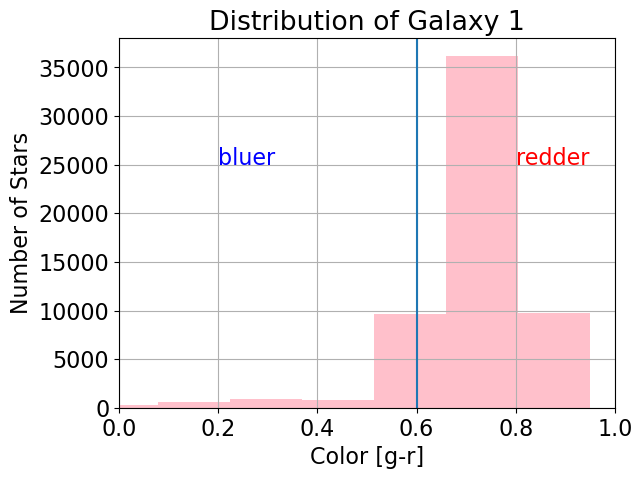

In [21]:
# galaxy 1

# grab the columns we want
g_band = data1['g band']
r_band = data1['r band']
# calculate the color
g_r = g_band - r_band
#create a histogram of the color. label the blue and red side. title your plot the galaxy name. calculate the mean color
plt.hist(g_r, color='pink')
plt.title('Distribution of Galaxy 1')
plt.xlabel('Color [g-r]')
plt.ylabel('Number of Stars')
plt.xlim(0, 1)

# Calculate the mean
round(np.mean(g_r), 2)

# Create a vertical line
plt.axvline(0.6)

# Add text
plt.text(0.2, 25000, 'bluer', color='blue')
plt.text(0.8, 25000, 'redder', color='red')

plt.grid()

In [22]:
data2

,g band,r band,age [Gyr]
0,-7.309444,-8.195689,10.856031
1,-8.330170,-9.236679,7.855232
2,-7.083546,-8.048851,10.707024
3,-7.120369,-8.064854,10.323297
4,-7.432516,-8.354740,10.332248
...,...,...,...
77402,-9.114698,-9.758924,6.082449
77403,-7.966639,-8.690153,9.271124
77404,-9.177384,-9.924151,6.693040
77405,-8.440053,-9.096263,3.975184


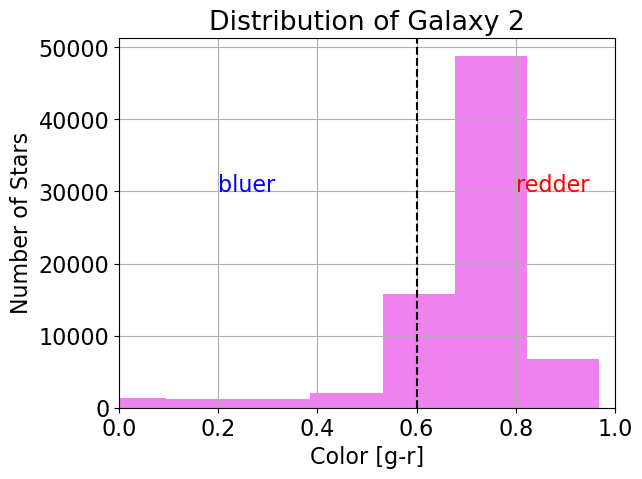

In [29]:
# galaxy 2

# grab the columns we want
g_band2 = data2['g band']
r_band2 = data2['r band']
# calculate the color
g2_r2 = g_band2 - r_band2 
#create a histogram of the color. label the blue and red side. title your plot the galaxy name. calculate the mean color
plt.hist(g2_r2, color='violet', alpha=1)
plt.title('Distribution of Galaxy 2')
plt.xlabel('Color [g-r]')
plt.ylabel('Number of Stars')
plt.xlim(0, 1)

# Add a line
plt.axvline(0.6, color='black', ls='--')

# Calculate the mean
round(np.mean(g2_r2), 2)

# Add text
plt.text(0.2, 30000, 'bluer', color='blue')
plt.text(0.8, 30000, 'redder', color='red')

plt.grid()

In [30]:
data3

,g band,r band,age [Gyr]
0,-8.046761,-8.816961,6.347111
1,-8.000262,-8.888894,7.544227
2,-8.242189,-9.012588,6.360210
3,-7.937858,-8.843595,7.517226
4,-8.133110,-8.992483,6.843228
...,...,...,...
63168,-8.388541,-9.066907,9.109745
63169,-9.321708,-9.870861,12.149096
63170,0.000000,0.000000,13.800000
63171,-8.236311,-8.718164,13.085381


C:\Users\gf3775\AppData\Local\Temp\ipykernel_19528\3309348496.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


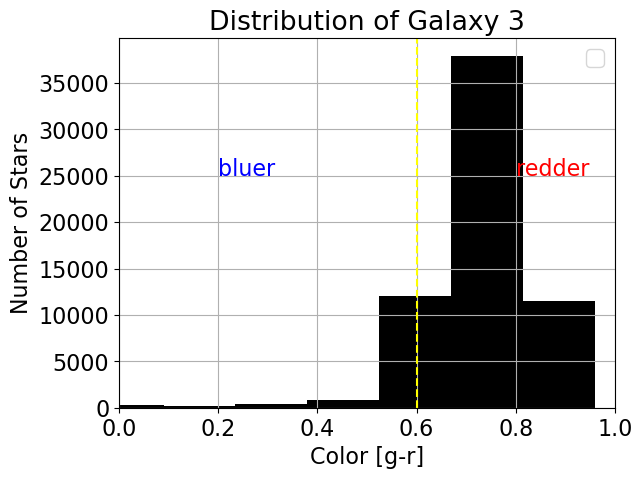

In [39]:
# galaxy 3

# grab the columns we want
g_band3 = data3['g band']
r_band3 = data3['r band']
# calculate the color
g3_r3 = g_band3 - r_band3
#create a histogram of the color. label the blue and red side. title your plot the galaxy name. calculate the mean color
plt.hist(g3_r3, color='black')
plt.title('Distribution of Galaxy 3')
plt.xlabel('Color [g-r]')
plt.ylabel('Number of Stars')
plt.xlim(0, 1)

# Add the vertical line
plt.axvline(0.6, color='yellow', ls='--')
# Calculate the mean
round(np.mean(g3_r3), 2)

# Add text
plt.text(0.2, 25000, 'bluer', color='blue')
plt.text(0.8, 25000, 'redder', color='red')

plt.grid()
plt.legend()

**What did you find?**

**Answer:** All of the three galaxies are redder, which means they are all older galaxies.

**Where your predictions correct?**

**Answer** I got two of them right, but I got one wrong.

**What does this mean astronomically?**

**Answer:** There are more older galaxies than newer galaxies.

Go back to your stars notebook where you plotted color vs age. Recreate that plot here. Add all 3 of the simulated galaxies your chose to one single plot. Be sure to distinguish between the 3 galaxies with color and marker style.

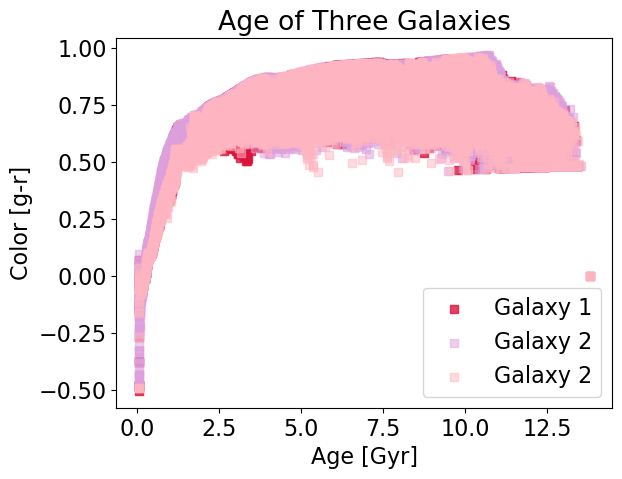

In [53]:
# color vs age

# pull out the age data from each of the 3 galaxies
age1 = data1['age [Gyr]']
age2 = data2['age [Gyr]']
age3 = data3['age [Gyr]']

# scatter plot of color vs age in all 3 galaxies. try experimenting with "alpha" so you can see the data
# Galaxy 1
plt.scatter (age1, g_r, color='crimson', alpha=0.8, marker='s', label='Galaxy 1')
plt.title('Age of Three Galaxies')
plt.xlabel('Age [Gyr]')
plt.ylabel('Color [g-r]')
# Galaxy 2
plt.scatter(age2, g2_r2, color='plum', alpha=0.5, marker='s', label='Galaxy 2')
# Galaxy 3
plt.scatter(age3, g3_r3, color='lightpink', alpha=0.5, marker ='s', label='Galaxy 2')

plt.legend()

**According to your graph set up...**

**What is the independent variable?**

**Answer:** Age 

**What is the dependent variable?**

**Answer:** Color

**Do the Gaia stars and IllustrisTNG stars have a similar age range?**

**Answer:** No, Gaia stars are older than IllustrisTNG.

**Do the Gaia stars and IllustrisTNG stars have a similar color range?**

**Answer:** 

**What shapes or trends do you see in the data?**

**Answer:** 

**Do your three galaxies have a similar or different trends?**

**Answer:** 

**Do you reach the same conclusion for physical meaning that you did with the Gaia stars?**

**Answer:** 

**What does this mean about the galaxies you chose? What could be their minimum age?**

**Answer:** 